In [1]:
# Load utility functions and libraries
from bitcoin_utils import (
    fetch_historical_bitcoin_prices,
    fetch_current_price,
    save_to_sqlite,
    init_db,
    calculate_moving_averages,
    calculate_volatility,
    detect_anomalies_zscore,
    generate_trend_indicators,
    decompose_time_series
)

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# Ensure the DB and table exist
init_db()


In [3]:
# Get historical Bitcoin price data (last 365 days)
df_hist = fetch_historical_bitcoin_prices()
save_to_sqlite(df_hist, "data/bitcoin_data.db")
df_hist.tail()


,timestamp,price
361,2025-05-08 00:00:00,97026.493770
362,2025-05-09 00:00:00,103076.275555
363,2025-05-10 00:00:00,102962.540457
364,2025-05-11 00:00:00,104630.879299
365,2025-05-11 21:57:30,104310.535248


In [4]:
# (Optional) Fetch and save current price snapshot
df_now = fetch_current_price()
save_to_sqlite(df_now, "data/bitcoin_data.db")
df_now


,timestamp,price
0,2025-05-11 21:58:03.696115+00:00,104254


In [7]:
# Load all saved price data from SQLite
conn = sqlite3.connect("data/bitcoin_data.db")
df = pd.read_sql_query("SELECT * FROM bitcoin_prices", conn)
conn.close()

df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True, errors='coerce')
df = df.sort_values("timestamp")
df.tail()


,id,timestamp,price
1097,1098,2025-05-11 00:00:00+00:00,104630.879299
731,732,2025-05-11 21:54:25+00:00,104199.093282
732,733,2025-05-11 21:57:20.613604+00:00,104238.000000
1098,1099,2025-05-11 21:57:30+00:00,104310.535248
1099,1100,2025-05-11 21:58:03.696115+00:00,104254.000000


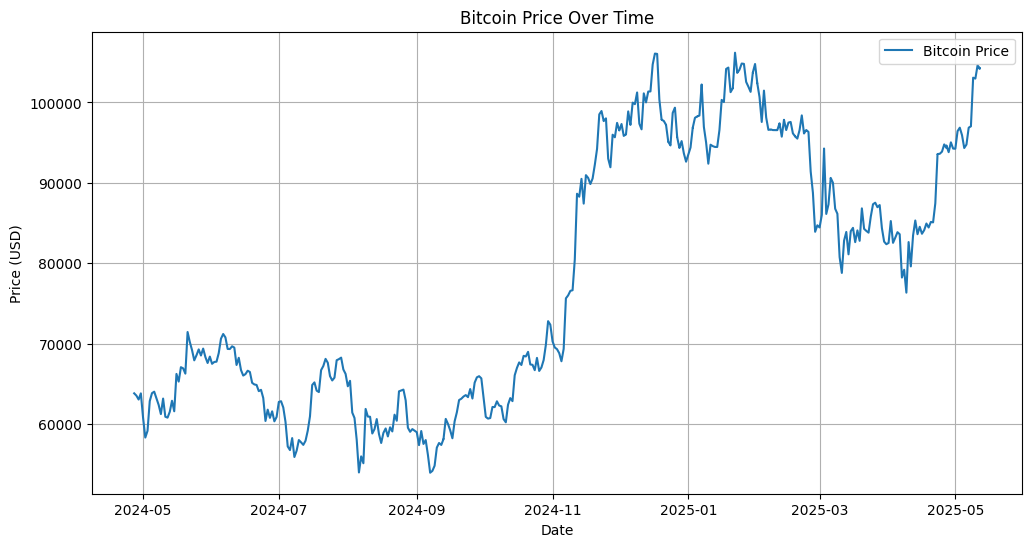

In [8]:
# Basic line chart
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['price'], label='Bitcoin Price')
plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


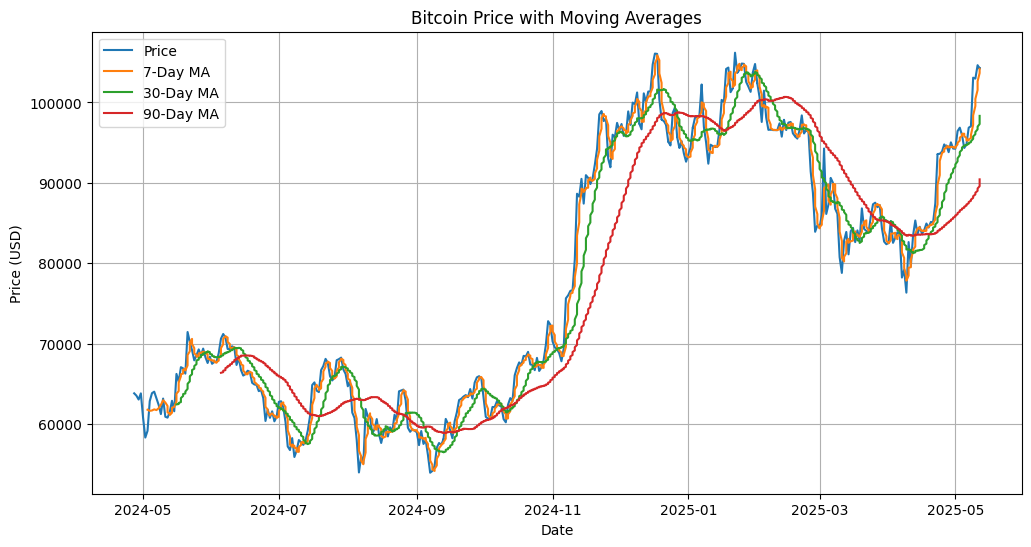

In [9]:
df_ma = calculate_moving_averages(df)

plt.figure(figsize=(12, 6))
plt.plot(df_ma['timestamp'], df_ma['price'], label='Price')
plt.plot(df_ma['timestamp'], df_ma['MA_7'], label='7-Day MA')
plt.plot(df_ma['timestamp'], df_ma['MA_30'], label='30-Day MA')
plt.plot(df_ma['timestamp'], df_ma['MA_90'], label='90-Day MA')
plt.title("Bitcoin Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


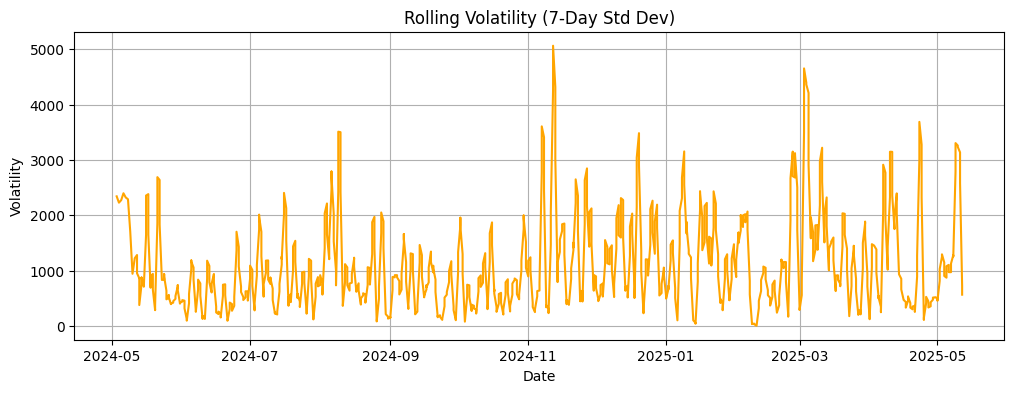

In [10]:
df_vol = calculate_volatility(df)

plt.figure(figsize=(12, 4))
plt.plot(df_vol['timestamp'], df_vol['volatility'], color='orange')
plt.title("Rolling Volatility (7-Day Std Dev)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()


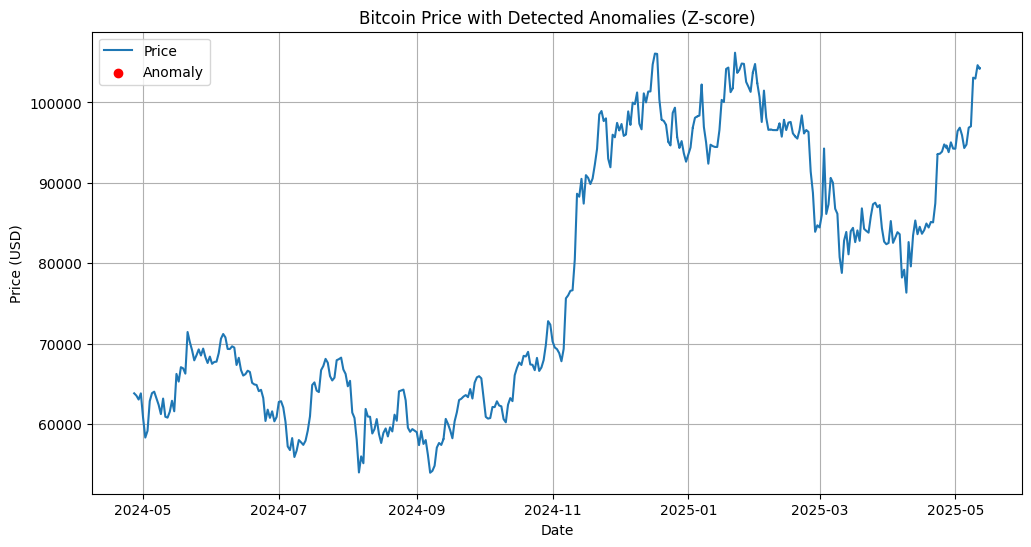

In [11]:
df_anom = detect_anomalies_zscore(df)

plt.figure(figsize=(12, 6))
plt.plot(df_anom['timestamp'], df_anom['price'], label='Price')
plt.scatter(df_anom[df_anom['anomaly_z']]['timestamp'], 
            df_anom[df_anom['anomaly_z']]['price'],
            color='red', label='Anomaly', zorder=5)
plt.title("Bitcoin Price with Detected Anomalies (Z-score)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


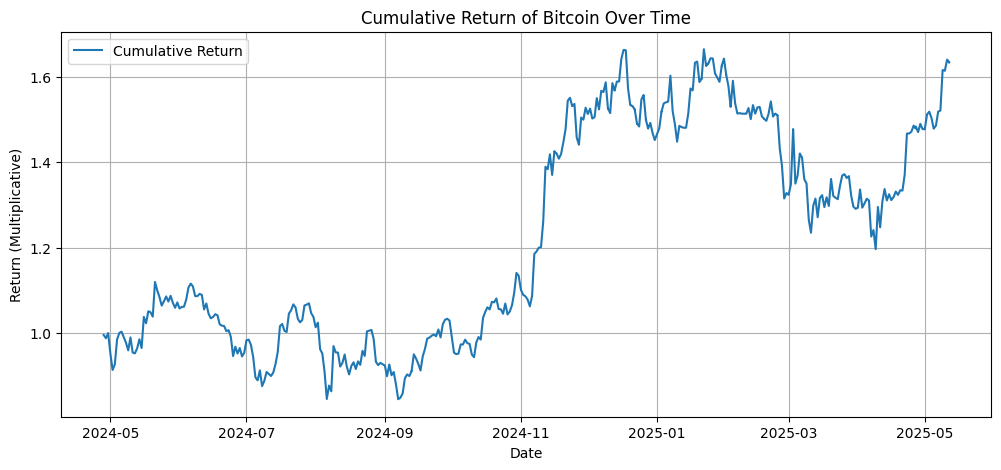

In [12]:
df_trend = generate_trend_indicators(df)

plt.figure(figsize=(12, 5))
plt.plot(df_trend['timestamp'], df_trend['cumulative_return'], label='Cumulative Return')
plt.title("Cumulative Return of Bitcoin Over Time")
plt.xlabel("Date")
plt.ylabel("Return (Multiplicative)")
plt.grid(True)
plt.legend()
plt.show()


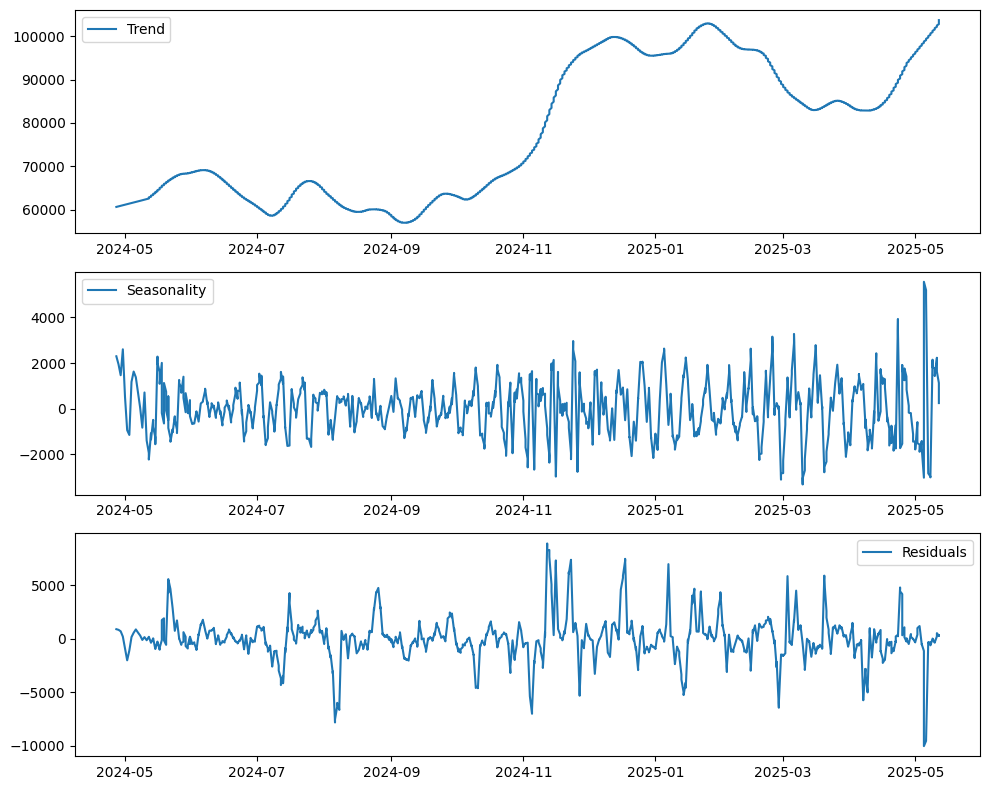

In [13]:
decomp_df = decompose_time_series(df, period=30, plot=True)


## Summary

This notebook demonstrates a full real-time Bitcoin data pipeline:

- Data is fetched via CoinGecko and stored in SQLite
- Time series analytics include:
  - Moving Averages
  - Volatility estimation
  - Anomaly detection using Z-score
  - Cumulative return and trend indicators
  - STL decomposition of the price signal

These tools can help identify trading patterns, detect outliers, and monitor price stability in dynamic markets like crypto.
